In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

from itertools import groupby
import statistics

import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns


In [2]:
TRAIN_PATH = "../raw_data/train.parquet"

In [3]:
pf = pq.ParquetFile(TRAIN_PATH)
columns = pf.schema.names
num_rows = pf.metadata.num_rows

print("columns: ", columns)
print("number of rows: ", num_rows)
print("measurements pro minute: ", num_rows / 14 / 365 / 24 / 60)

columns:  ['id', 'channel_1', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_2', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26', 'channel_27', 'channel_28', 'channel_29', 'channel_3', 'channel_30', 'channel_31', 'channel_32', 'channel_33', 'channel_34', 'channel_35', 'channel_36', 'channel_37', 'channel_38', 'channel_39', 'channel_4', 'channel_40', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46', 'channel_47', 'channel_48', 'channel_49', 'channel_5', 'channel_50', 'channel_51', 'channel_52', 'channel_53', 'channel_54', 'channel_55', 'channel_56', 'channel_57', 'channel_58', 'channel_59', 'channel_6', 'channel_60', 'channel_61', 'channel_62', 'channel_63', 'channel_64', 'channel_65', 'channel_66', 'channel_67', 'channel_68', 'channel_69', 'channel_7', 'channel_70', 'channel_71', 'channel_72', 'channel_7

In [5]:
stats = []

for col_name in columns[1:-1]:

  column = pq.read_table(TRAIN_PATH, columns=[col_name])
  column = column.column(col_name).to_pandas()

  stats.append({
        "column": col_name,
        "mean": column.mean(),
        "std": column.std(),
        "min": column.min(),
        "max": column.max(),
        "nunique": column.nunique()
    })

#with pd.option_context('display.max_rows', None):
#    display(pd.DataFrame(stats).set_index("column"))


In [6]:
anomaly = pq.read_table(TRAIN_PATH, columns=["is_anomaly"])
anomaly = anomaly.column("is_anomaly").to_pandas()

shortest anomaly:  1
median anomaly:  601.5
longest anomaly:  116061


(array([147.,  13.,  20.,   7.,   1.,   1.,   0.,   0.,   0.,   1.]),
 array([1.00000e+00, 1.16070e+04, 2.32130e+04, 3.48190e+04, 4.64250e+04,
        5.80310e+04, 6.96370e+04, 8.12430e+04, 9.28490e+04, 1.04455e+05,
        1.16061e+05]),
 <BarContainer object of 10 artists>)

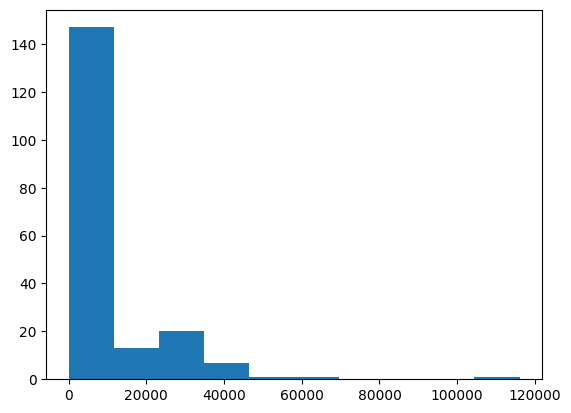

In [7]:
lengths = [len(list(g)) for k, g in groupby(anomaly) if k == 1]

print('shortest anomaly: ', min(lengths))
print('median anomaly: ', statistics.median(lengths))
print('longest anomaly: ', max(lengths))
plt.hist(lengths)

In [8]:
def plot_column(col, width, start):

    column = pq.read_table(TRAIN_PATH, columns=[col])
    column = column.column(col).to_pandas()

    r = range(start, min(num_rows, start+width))
    #lims = (column.min(), column.max())

    mask = anomaly.iloc[r] == 1

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].plot(r, column.iloc[r])
    axes[0].scatter(np.array(r)[mask], column.iloc[r][mask], color='red', s=10)
    #axes[0].set_ylim(lims)
    axes[1].plot(r, column.iloc[r].rolling(window=251, center=True).median())
    #axes[1].set_ylim(lims)
    axes[2].hist(column, bins=10)


In [9]:
widgets.interact(
    plot_column,
    col=widgets.Dropdown(options=columns[1:-1], description="Column"),
    width=widgets.IntSlider(min=100, max=1000000, step=100, value=500, description="Width"),
    start=widgets.IntSlider(min=0, max=num_rows-1, step=1000, description="Start"))

interactive(children=(Dropdown(description='Column', options=('channel_1', 'channel_10', 'channel_11', 'channe…

<function __main__.plot_column(col, width, start)>

In [6]:
from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR
OVERVIEW_CHANNELS = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']

In [30]:
def plot_with_anomaly(channels, start=0, end=num_rows):
    
    SAMPLE_FRAC = min(1.0, 280000 / (end-start))

    # load first N ids + anomaly
    meta_2m = pq.read_table(TRAIN_PATH, columns=['id', 'is_anomaly']).to_pandas()
    meta_2m = meta_2m.sort_values('id').iloc[start:end]

    # sample within first 2M
    sample_2m = meta_2m.sample(frac=SAMPLE_FRAC, random_state=42).sort_values('id')

    idx_2m = sample_2m['id'].values
    anom_2m = sample_2m['is_anomaly'].values

    # load channels column-wise
    data_2m = {'id': idx_2m, 'is_anomaly': anom_2m}

    for col in channels:
        df_col = pq.read_table(TRAIN_PATH, columns=['id', col]).to_pandas().set_index('id')

        # faster alignment vs isin
        values = df_col.reindex(idx_2m)[col].values
        data_2m[col] = values

    train_2m = pd.DataFrame(data_2m).set_index('id')

    # plotting
    n_ch = len(channels)
    fig, axes = plt.subplots(n_ch, 1, figsize=(18, 2.2 * n_ch), sharex=True)

    for ax, ch in zip(axes, channels):
        ax.plot(train_2m.index, train_2m[ch].values, lw=0.5, color=NOMINAL_COLOR, alpha=0.8)

        # anomaly shading
        in_anom = False
        start = None

        idx_arr = train_2m.index.values
        lab_arr = train_2m['is_anomaly'].values

        for i in range(len(idx_arr)):
            if lab_arr[i] == 1 and not in_anom:
                start = idx_arr[i]
                in_anom = True
            elif lab_arr[i] == 0 and in_anom:
                ax.axvspan(start, idx_arr[i], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)
                in_anom = False

        if in_anom:
            ax.axvspan(start, idx_arr[-1], color=ANOMALY_COLOR, alpha=0.3, linewidth=0)

        ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=55, va='center')
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.4)

    axes[0].set_title(
        f'12 Target Channels - First 2M Rows ({SAMPLE_FRAC:.0%} sample)',
        fontsize=12, fontweight='bold'
    )

    axes[-1].set_xlabel('Row index (time →)', fontsize=9)
    axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

    anom_patch = mpatches.Patch(color=ANOMALY_COLOR, alpha=0.4, label='Anomaly region')
    axes[0].legend(handles=[anom_patch], fontsize=8, loc='upper right')

    fig.tight_layout()
    plt.show()

0.019010992495342816


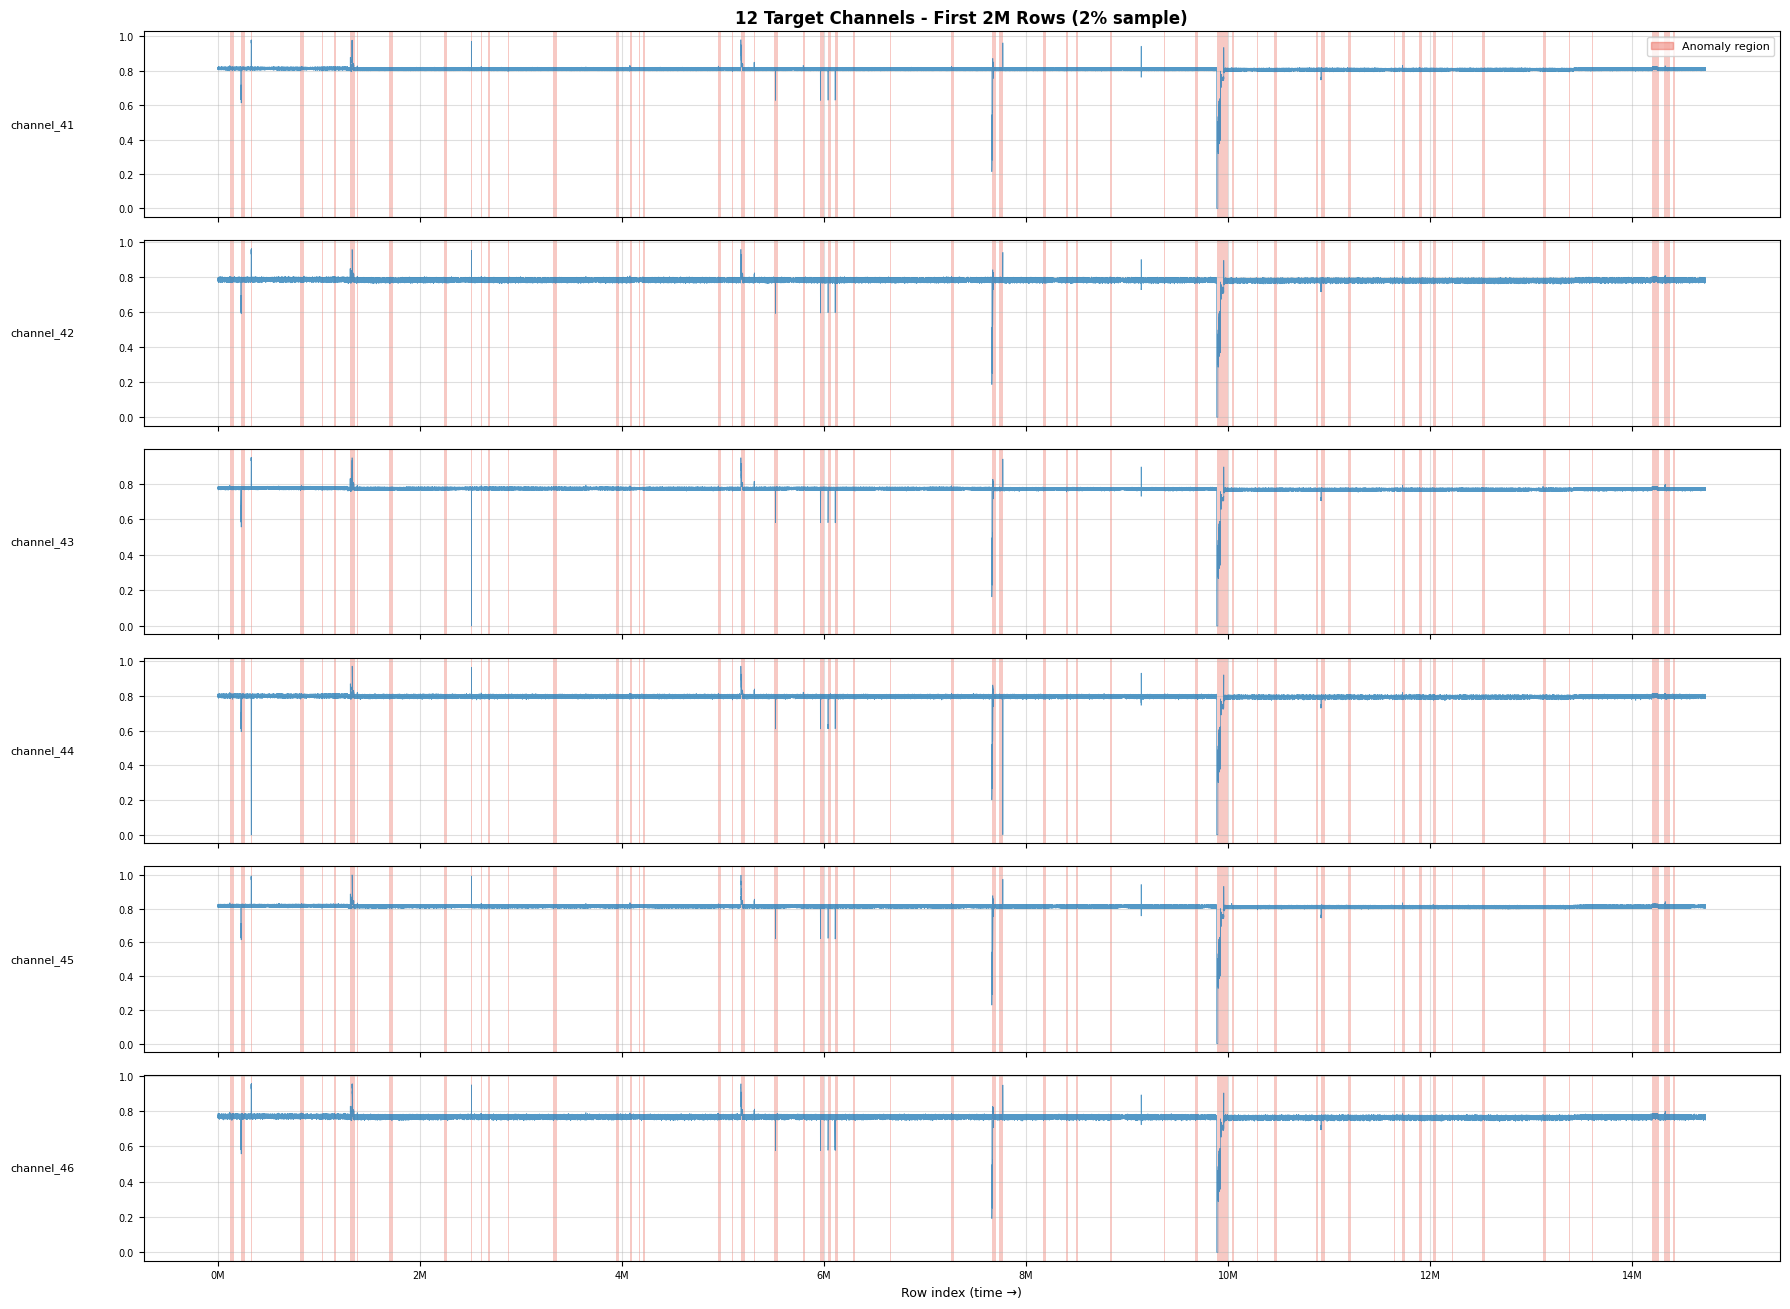

In [14]:
plot_with_anomaly(OVERVIEW_CHANNELS)

0.14


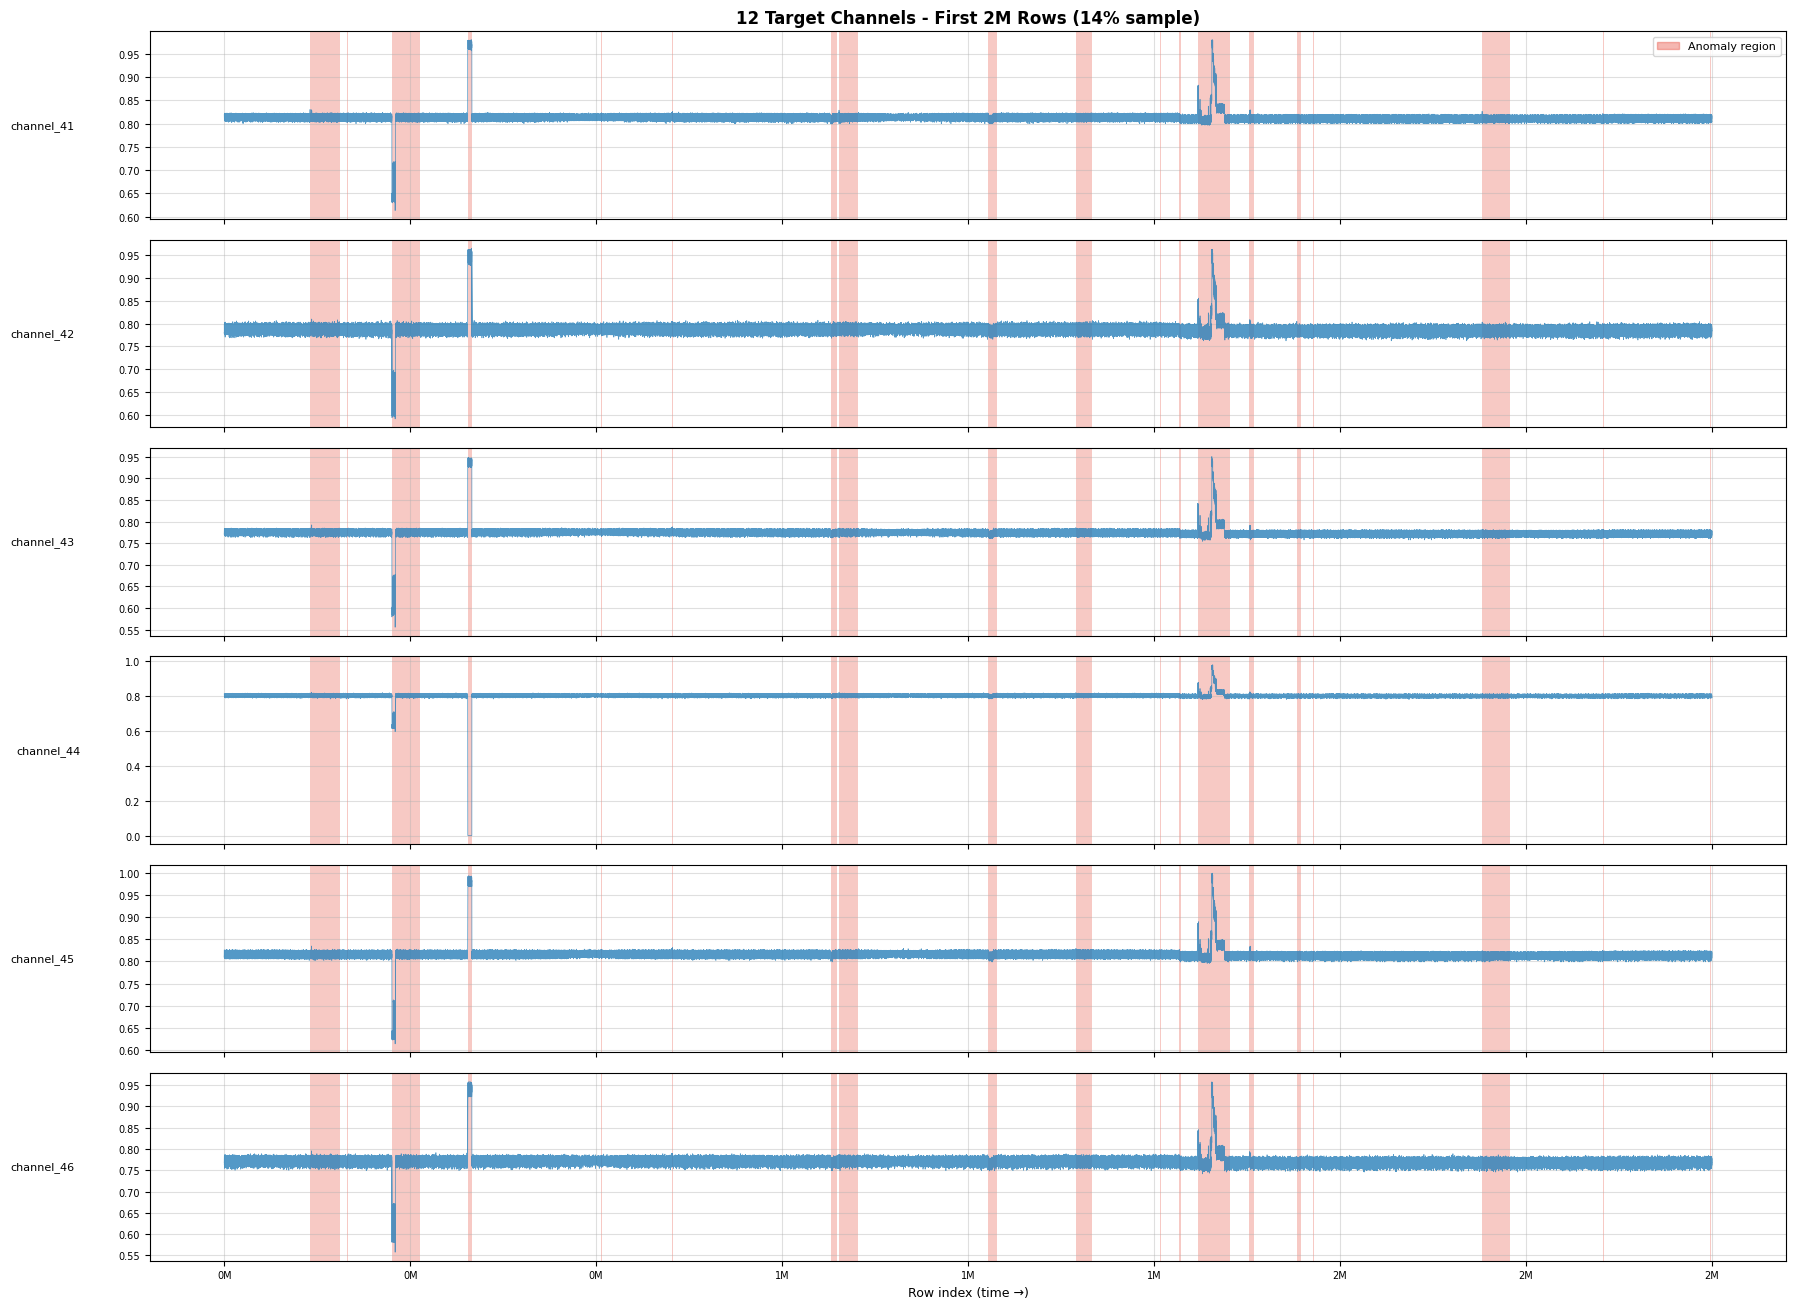

In [ ]:
pplot_with_anomaly(OVERVIEW_CHANNELS)

0.7


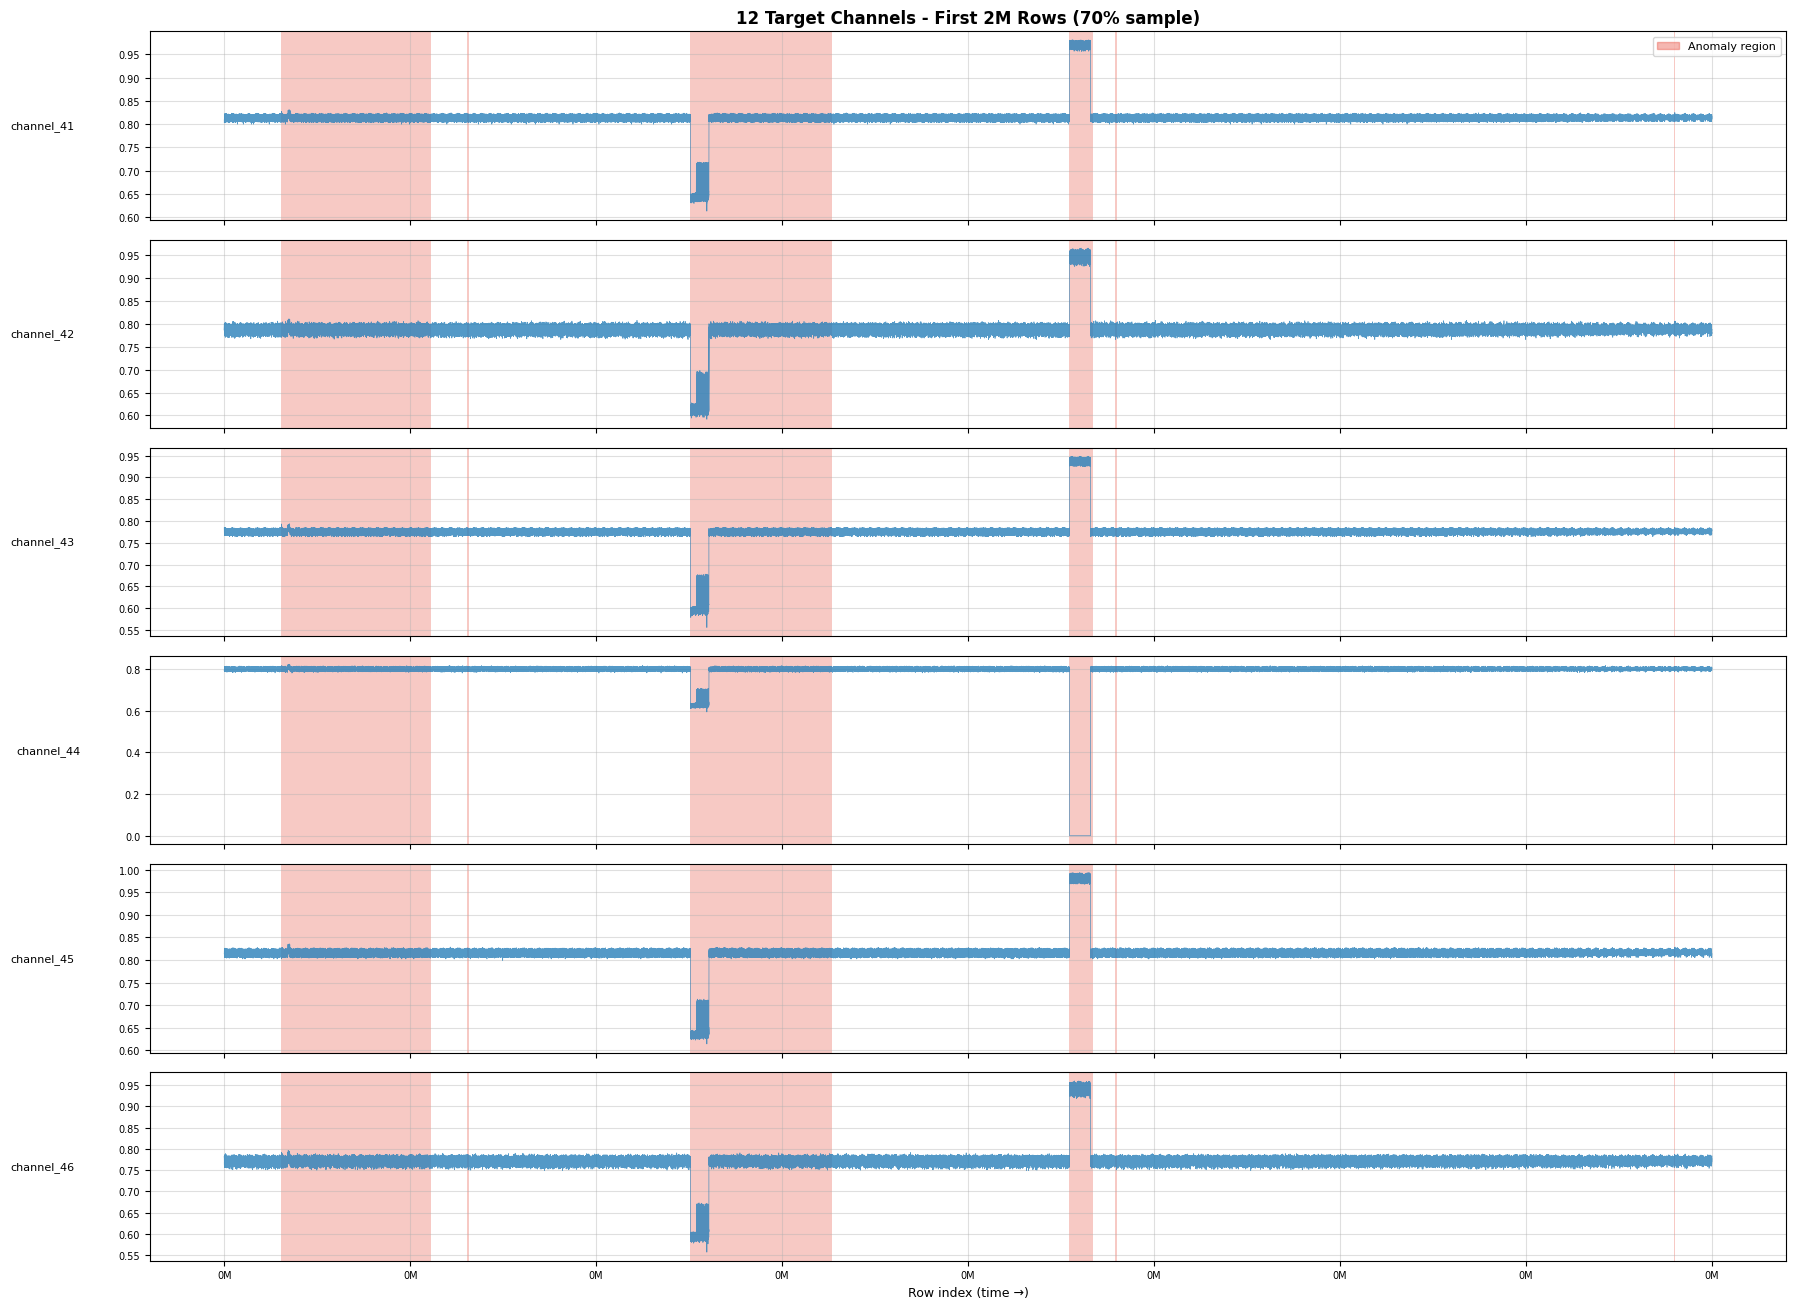

In [16]:
plot_with_anomaly(OVERVIEW_CHANNELS, 100_000, 500_000)

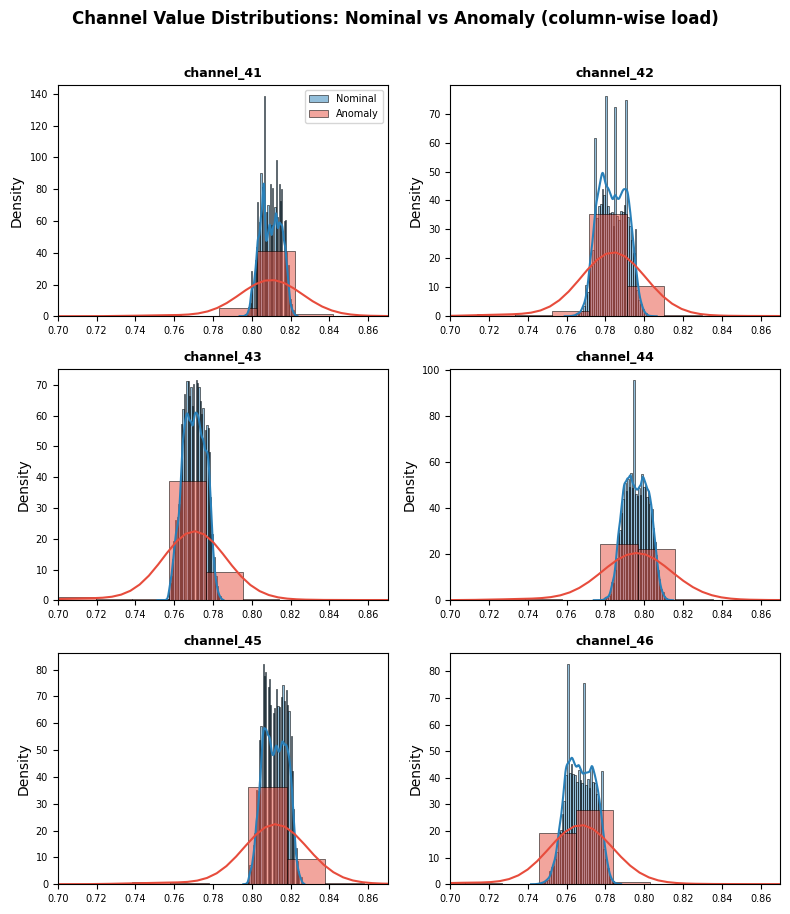

In [29]:
# 1. sample indices
SAMPLE_N = 100_000

meta = pq.read_table(TRAIN_PATH, columns=["id", "is_anomaly"]).to_pandas()
sample_meta = meta.sample(n=SAMPLE_N, random_state=42)

idx_sample = sample_meta["id"].values
anom_sample = sample_meta["is_anomaly"].values

# split masks once to avoid recomputation
nom_mask = anom_sample == 0
anom_mask = anom_sample == 1

# 2. plotting layout
DIST_CHANNELS = OVERVIEW_CHANNELS

ncols = 2
nrows = int(np.ceil(len(DIST_CHANNELS) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

# 3. load each column separately
for i, ch in enumerate(DIST_CHANNELS):
    ax = axes[i]

    # load only index + current channel
    df = pq.read_table(TRAIN_PATH, columns=["id", ch]).to_pandas().set_index("id")

    # align to sampled indices
    values = df.loc[idx_sample, ch].values

    nom_values = values[nom_mask]
    anom_values = values[anom_mask]

    # plot distributions
    sns.histplot(nom_values, ax=ax, color=NOMINAL_COLOR, alpha=0.5, stat="density", bins=50, kde=True, label="Nominal")
    sns.histplot(anom_values, ax=ax, color=ANOMALY_COLOR, alpha=0.5, stat="density", bins=50, kde=True, label="Anomaly")

    ax.set_title(ch, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
    ax.set_xlim(0.7, 0.87)

    if i == 0:
        ax.legend(fontsize=7)

# hide unused subplots
for j in range(len(DIST_CHANNELS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Channel Value Distributions: Nominal vs Anomaly (column-wise load)", fontsize=12, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

In [39]:
names = ['channel_' + str(n) for n in range(12, 20)]
names

['channel_12',
 'channel_13',
 'channel_14',
 'channel_15',
 'channel_16',
 'channel_17',
 'channel_18',
 'channel_19']

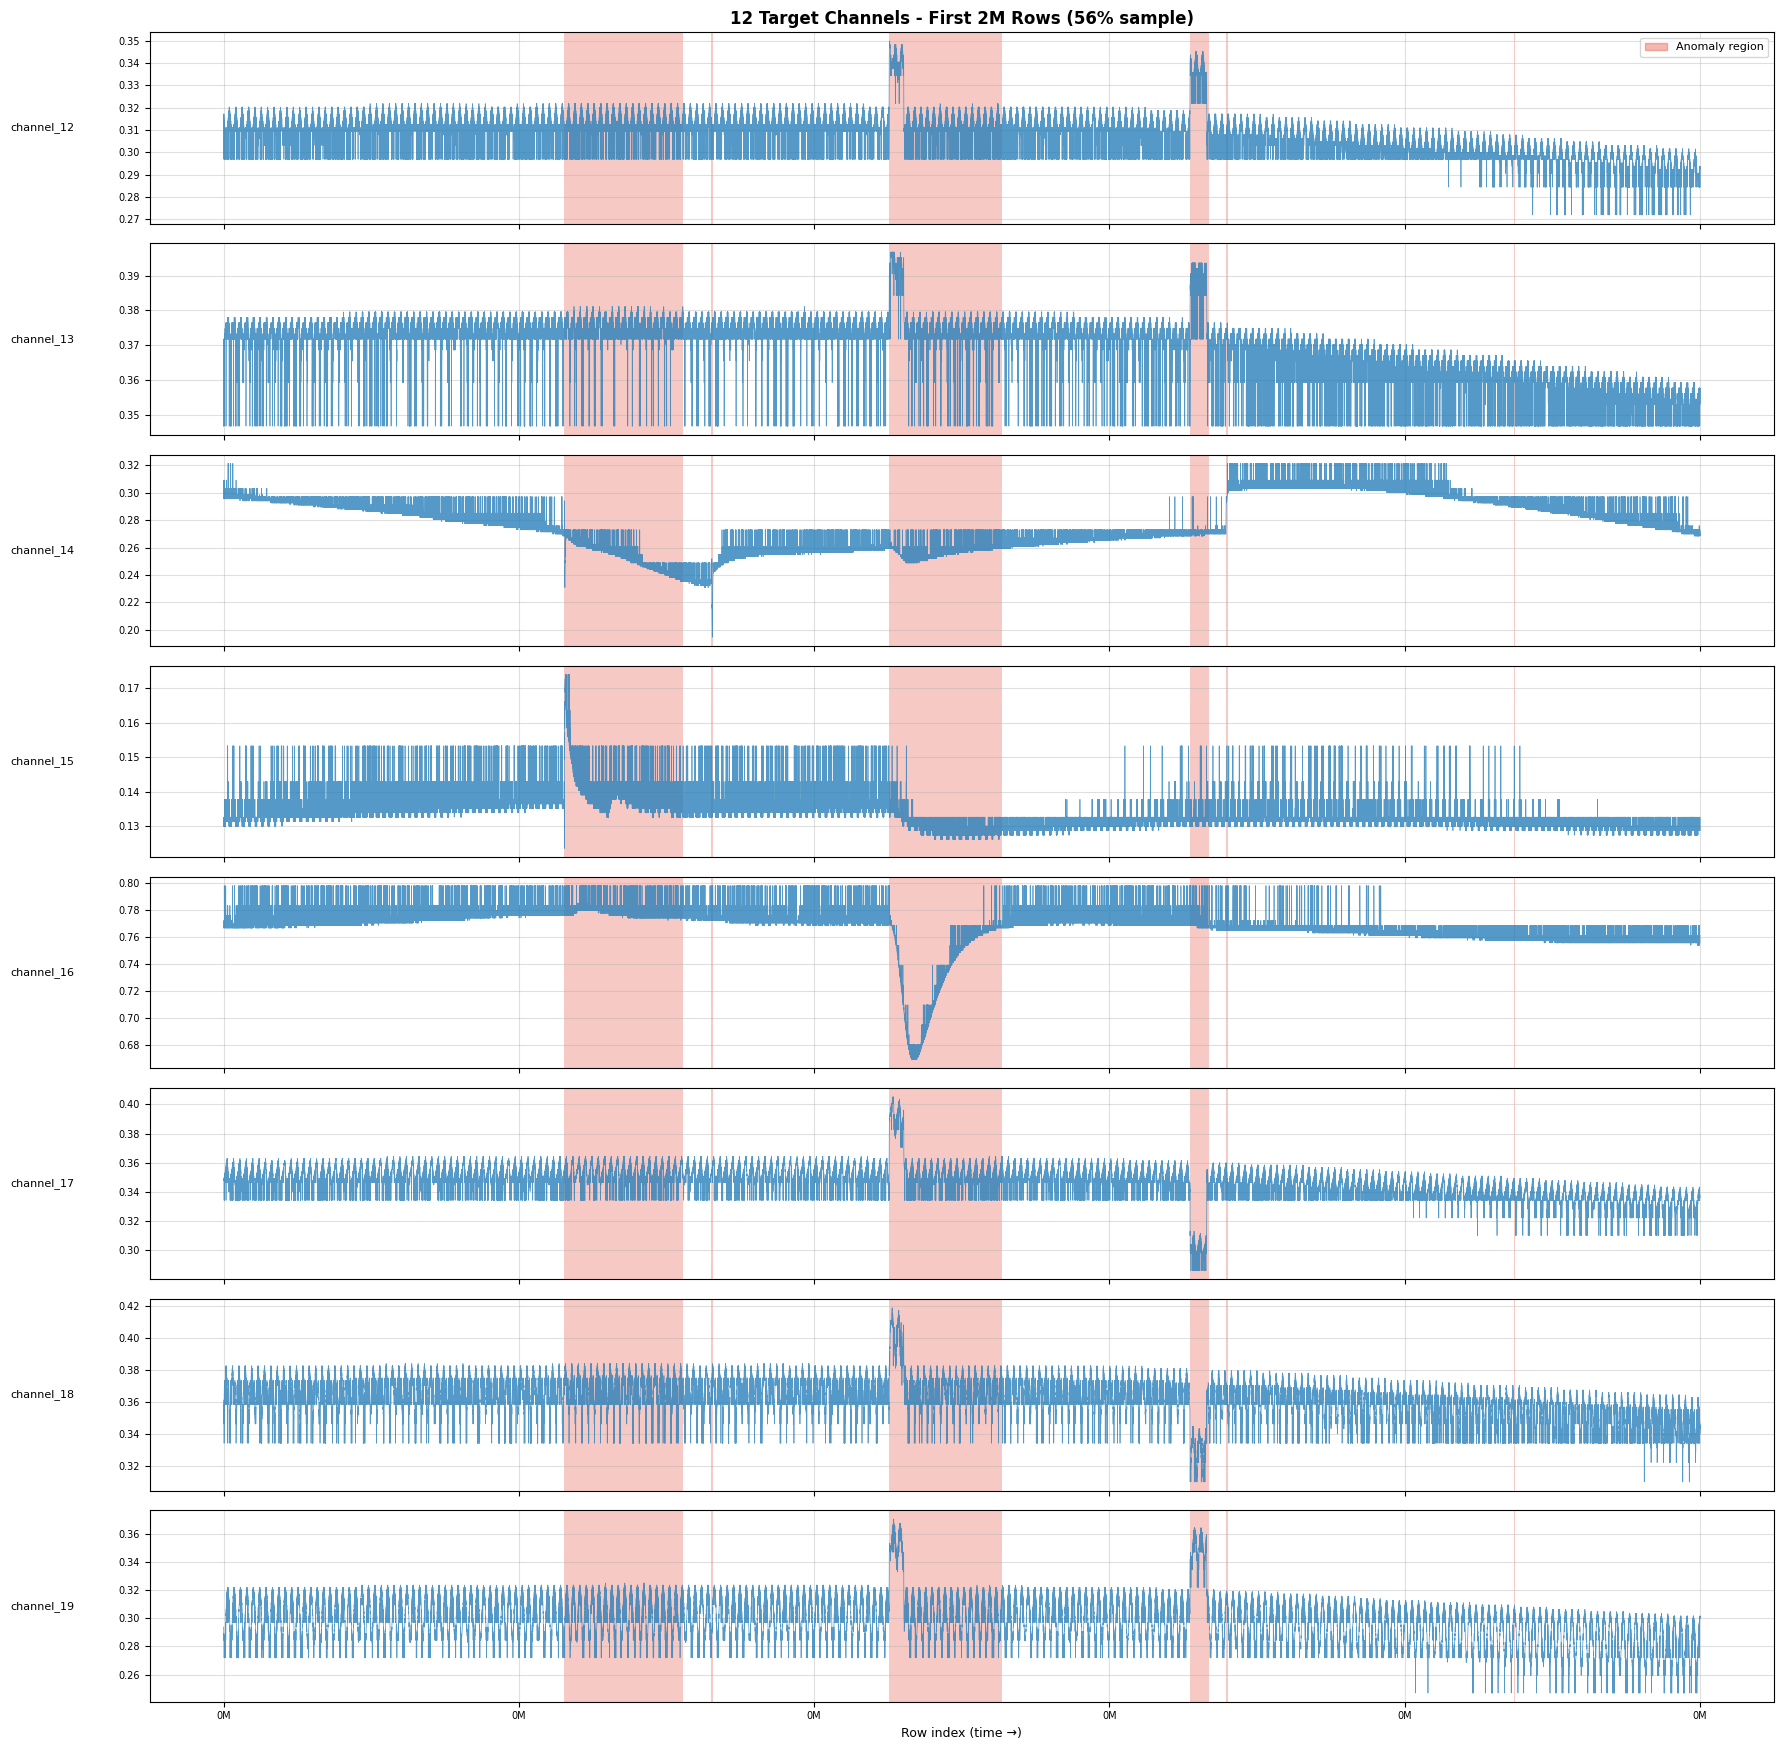

In [40]:
plot_with_anomaly(names, 0, 500_000)